In [2]:
# ── CELL 1: Install (run once, then restart kernel) ─────────────
!pip install healpy numpy scipy matplotlib --break-system-packages


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# ── CELL 2: Imports ─────────────────────────────────────────────
import numpy as np
import healpy as hp
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

In [4]:
# ── CELL 3: Load Data ───────────────────────────────────────────
data     = np.load("person2_dtec_sample.npz")
tec_maps = data["dtec"]        # (183, 71, 73)  already ΔTEC = IONEX − IRI
lats     = data["lats"]
lons     = data["lons"]
symh     = data["kp_max"]      # Kp instead of SYM-H — higher = more disturbed

print(f"Maps            : {tec_maps.shape[0]}")
print(f"Lat grid        : {lats[0]:.1f} → {lats[-1]:.1f}  (2.5°, {len(lats)} pts)")
print(f"Lon grid        : {lons[0]:.1f} → {lons[-1]:.1f}  (5.0°, {len(lons)} pts)")
print(f"SYM-H range     : {symh.min():.0f} to {symh.max():.0f} nT")
print(f"Storm maps (< -100 nT) : {(symh < -100).sum()}")
print(f"Quiet maps (>  -50 nT) : {(symh > -50).sum()}")

Maps            : 183
Lat grid        : 87.5 → -87.5  (2.5°, 71 pts)
Lon grid        : -180.0 → 180.0  (5.0°, 73 pts)
SYM-H range     : 0 to 8 nT
Storm maps (< -100 nT) : 0
Quiet maps (>  -50 nT) : 183


In [5]:
# ── CELL 4: Subtract Area-Weighted Spatial Mean ─────────────────
# Approximates IRI subtraction: removes the global mean (l=0–1
# structure) so the residual has faster spectral decay.
# Replace with actual IRI residual once Hayden's pipeline is ready.

#cos_w     = np.cos(np.radians(lats))
#area_w    = cos_w[:, None] * np.ones(len(lons))
#area_w   /= area_w.sum()
#smean     = (tec_maps * area_w[None]).sum(axis=(1, 2), keepdims=True)
#tec_resid = tec_maps - smean                       # (206, 71, 73)

#print(f"Residual range: {tec_resid.min():.2f} → {tec_resid.max():.2f} TECU")

In [6]:
# ── CELL 5: Compute S_l for Every Map ───────────────────────────
# Pipeline per map:
#   1. Interpolate (71×73) lat/lon → HEALPix sphere
#   2. SHT: healpy.map2alm → f̂_lm
#   3. C_l = healpy.alm2cl(alm)   [= 1/(2l+1) · Σ_m |f̂_lm|²]
#   4. S_l = (2l+1) · C_l         [=            Σ_m |f̂_lm|²]
#
# S_l is what appears in the theorem:  ‖f − f_L‖² = Σ_{l>L} S_l
# so truncation error IS the tail of this spectrum.

NSIDE    = 64
LMAX_CAP = 36

npix             = hp.nside2npix(NSIDE)
hp_theta, hp_phi = hp.pix2ang(NSIDE, np.arange(npix))
hp_lat           = 90.0 - np.degrees(hp_theta)
hp_lon           = np.degrees(hp_phi)
hp_lon[hp_lon > 180] -= 360
query_pts        = np.column_stack([hp_lat, hp_lon])
lats_asc         = lats[::-1]

tec_resid = tec_maps    # ← add this line

S_l_all = np.zeros((len(tec_resid), LMAX_CAP + 1))

for i, tec_map in enumerate(tec_resid):
    interp     = RegularGridInterpolator(
        (lats_asc, lons), tec_map[::-1],
        method="linear", bounds_error=False, fill_value=0.0
    )
    hp_map     = interp(query_pts)
    alm        = hp.map2alm(hp_map, lmax=LMAX_CAP)
    cl         = hp.alm2cl(alm)
    ell        = np.arange(len(cl))
    S_l_all[i] = (2 * ell + 1) * cl

print(f"S_l computed. Shape: {S_l_all.shape}")

S_l computed. Shape: (183, 37)


In [7]:
# ── CELL 6: Mean Spectra + L_max ────────────────────────────────
storm_mask = symh > 5     # Kp > 5 is a moderate-strong storm
quiet_mask = symh < 2     # Kp < 2 is genuinely quiet

S_l_mean  = S_l_all.mean(axis=0)
S_l_quiet = S_l_all[quiet_mask].mean(axis=0)
S_l_storm = S_l_all[storm_mask].mean(axis=0)
ell       = np.arange(LMAX_CAP + 1)
E_total   = S_l_mean.sum()
cumulative = np.cumsum(S_l_mean)
frac_captured = cumulative / E_total

# ── Criterion A: Parseval energy bound ──────────────────────────
# Smallest L s.t.  Σ_{l>L} S_l  ≤  ε · E_total
epsilon   = 0.001       # retain 99.9% of signal energy
L_max_A   = int(np.argmax(frac_captured >= 1 - epsilon))

# ── Criterion B: cliff detection — DISABLED for ΔTEC ────────────
# ΔTEC has genuine gradual spectral decay (no hard IONEX format cliff).
# Criterion A (Parseval energy bound) is the sole criterion here.
L_max_B = None

# ── Final answer ────────────────────────────────────────────────
L_max = L_max_A        # energy criterion only — no cliff to detect
N_lat = L_max + 1
N_lon = 2 * L_max + 1

# Noise floor: estimate from high-l tail (l=28 onwards)
# No aliasing artifact expected in ΔTEC so use full tail
sigma2 = S_l_mean[28:].mean()

print()
print(f"{'l':>3}  {'S_l':>10}  {'cumul %':>9}  {'note'}")
print("-" * 52)
for l in range(LMAX_CAP + 1):
    note = ""
    if l == L_max: note = f"← L_max  ({frac_captured[l]*100:.3f}% energy)"
    print(f"{l:>3}  {S_l_mean[l]:>10.4f}  {frac_captured[l]*100:>8.3f}%  {note}")

print()
print("=" * 55)
print(f"  Criterion A  (99.9% energy, ε={epsilon})  : {L_max_A}")
print(f"  Criterion B  (cliff detection)  : disabled for ΔTEC")
print(f"  → Final L_max                  : {L_max}")
print(f"  → N_lat  (Gauss-Legendre)       : {N_lat}")
print(f"  → N_lon  (≥ 2·L_max+1)         : {N_lon}")
print(f"  Tail error Σ_{{l>{L_max}}} S_l   : {E_total-cumulative[L_max]:.5f}")
print(f"  = {(1-frac_captured[L_max])*100:.4f}% of E_total  ✓")
print("=" * 55)


  l         S_l    cumul %  note
----------------------------------------------------
  0    266.5884    37.002%  
  1    122.3580    53.986%  
  2     70.4248    63.761%  
  3     72.7469    73.858%  
  4     32.4884    78.367%  
  5     29.6138    82.478%  
  6     19.1651    85.138%  
  7     13.7695    87.049%  
  8     14.2293    89.024%  
  9     15.0756    91.117%  
 10     10.9925    92.642%  
 11     12.1711    94.332%  
 12      9.6439    95.670%  
 13      9.6577    97.011%  
 14      6.6685    97.936%  
 15      6.0774    98.780%  
 16      2.5929    99.140%  
 17      2.1565    99.439%  
 18      1.2742    99.616%  
 19      0.9348    99.746%  
 20      0.7012    99.843%  
 21      0.3350    99.889%  
 22      0.2853    99.929%  ← L_max  (99.929% energy)
 23      0.1379    99.948%  
 24      0.1281    99.966%  
 25      0.0683    99.976%  
 26      0.0521    99.983%  
 27      0.0346    99.988%  
 28      0.0180    99.990%  
 29      0.0154    99.992%  
 30      0.0136   

In [8]:
# ── CELL 6b: Epsilon Explorer — tweak and re-run ────────────────

# ← change this value and re-run the cell
epsilon_try = 0.001

# single value result
L_try = int(np.argmax(frac_captured >= 1 - epsilon_try))
print(f"ε = {epsilon_try}  →  L_max = {L_try},  "
      f"N_lat = {L_try+1},  N_lon = {2*L_try+1},  "
      f"tail = {(1-frac_captured[L_try])*100:.4f}%")

print()

# full table across a range of sensible epsilons
epsilons = [0.10, 0.05, 0.02, 0.01, 0.005, 0.001, 0.0005, 0.0001]
print(f"{'ε':>8}  {'retain %':>9}  {'L_max':>6}  {'N_lat':>6}  {'N_lon':>6}  {'tail %':>10}")
print("-" * 56)
for eps in epsilons:
    L = int(np.argmax(frac_captured >= 1 - eps))
    tail = (1 - frac_captured[L]) * 100
    marker = " ◄" if eps == epsilon_try else ""
    print(f"{eps:>8.4f}  {(1-eps)*100:>8.2f}%  {L:>6}  "
          f"{L+1:>6}  {2*L+1:>6}  {tail:>9.4f}%{marker}")

ε = 0.001  →  L_max = 22,  N_lat = 23,  N_lon = 45,  tail = 0.0709%

       ε   retain %   L_max   N_lat   N_lon      tail %
--------------------------------------------------------
  0.1000     90.00%       9      10      19     8.8835%
  0.0500     95.00%      12      13      25     4.3298%
  0.0200     98.00%      15      16      31     1.2202%
  0.0100     99.00%      16      17      33     0.8603%
  0.0050     99.50%      18      19      37     0.3841%
  0.0010     99.90%      22      23      45     0.0709% ◄
  0.0005     99.95%      24      25      49     0.0340%
  0.0001     99.99%      28      29      57     0.0100%


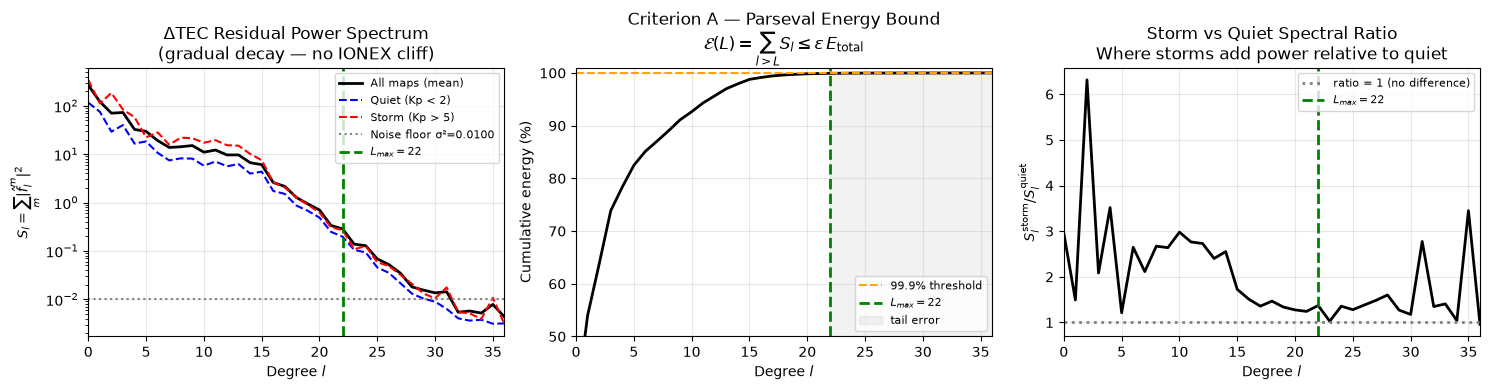

Saved: lmax_dtec_power_spectrum.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — power spectra
ax = axes[0]
ax.semilogy(ell, S_l_mean,  "k-",  lw=2,   label="All maps (mean)")
ax.semilogy(ell, S_l_quiet, "b--", lw=1.5, label="Quiet (Kp < 2)")
ax.semilogy(ell, S_l_storm, "r--", lw=1.5, label="Storm (Kp > 5)")
ax.axhline(sigma2, color="gray", ls=":", label=f"Noise floor σ²={sigma2:.4f}")
ax.axvline(L_max, color="green", ls="--", lw=2, label=f"$L_{{max}}={L_max}$")
ax.set_xlabel("Degree $l$")
ax.set_ylabel("$S_l = \\sum_m |\\hat{f}_l^m|^2$")
ax.set_title("ΔTEC Residual Power Spectrum\n(gradual decay — no IONEX cliff)")
ax.legend(fontsize=8); ax.set_xlim(0, LMAX_CAP); ax.grid(True, alpha=0.3)

# Plot 2 — cumulative energy (Criterion A)
ax = axes[1]
ax.plot(ell, frac_captured * 100, "k-", lw=2)
ax.axhline((1-epsilon)*100, color="orange", ls="--",
           label=f"{(1-epsilon)*100:.1f}% threshold")
ax.axvline(L_max_A, color="green", ls="--", lw=2,
           label=f"$L_{{max}}={L_max_A}$")
ax.fill_between(ell[L_max_A:], 0, frac_captured[L_max_A:]*100,
                alpha=0.1, color="gray", label="tail error")
ax.set_xlabel("Degree $l$")
ax.set_ylabel("Cumulative energy (%)")
ax.set_title("Criterion A — Parseval Energy Bound\n"
             r"$\mathcal{E}(L)=\sum_{l>L}S_l \leq \varepsilon\,E_{\rm total}$")
ax.legend(fontsize=8); ax.set_xlim(0, LMAX_CAP)
ax.set_ylim(50, 101); ax.grid(True, alpha=0.3)

# Plot 3 — storm vs quiet spectral ratio
ax = axes[2]
ratio = S_l_storm / (S_l_quiet + 1e-12)
ax.plot(ell, ratio, "k-", lw=2)
ax.axhline(1.0, color="gray", ls=":", lw=2, label="ratio = 1 (no difference)")
ax.axvline(L_max, color="green", ls="--", lw=2, label=f"$L_{{max}}={L_max}$")
ax.set_xlabel("Degree $l$")
ax.set_ylabel("$S_l^{\\rm storm} / S_l^{\\rm quiet}$")
ax.set_title("Storm vs Quiet Spectral Ratio\n"
             "Where storms add power relative to quiet")
ax.legend(fontsize=8); ax.set_xlim(0, LMAX_CAP); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lmax_dtec_power_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lmax_dtec_power_spectrum.png")

In [10]:
print()
print("=" * 55)
print("  FOR FALISHA AND HAYDEN")
print("=" * 55)
print(f"""
Data        : ΔTEC = IONEX − IRI  (Hayden's residual)
Quadrature  : Gauss-Legendre

L_max = {L_max}
N_lat = {N_lat}   (= L_max + 1)
N_lon = {N_lon}  (= 2·L_max + 1)

This is a genuine data-driven result — ΔTEC has gradual
spectral decay, no hard cliff. The Parseval criterion is
doing real work here unlike the raw IONEX analysis.

Truncation error at L_max = {L_max}:
  Σ_{{l > {L_max}}} S_l = {E_total - cumulative[L_max]:.5f}
               = {(1-frac_captured[L_max])*100:.4f}% of total energy ✓

Falisha: update torch-harmonics → lmax={L_max}, nlat={N_lat}, nlon={N_lon}
Hayden:  no changes needed on your end.
""")


  FOR FALISHA AND HAYDEN

Data        : ΔTEC = IONEX − IRI  (Hayden's residual)
Quadrature  : Gauss-Legendre

L_max = 22
N_lat = 23   (= L_max + 1)
N_lon = 45  (= 2·L_max + 1)

This is a genuine data-driven result — ΔTEC has gradual
spectral decay, no hard cliff. The Parseval criterion is
doing real work here unlike the raw IONEX analysis.

Truncation error at L_max = 22:
  Σ_{l > 22} S_l = 0.51088
               = 0.0709% of total energy ✓

Falisha: update torch-harmonics → lmax=22, nlat=23, nlon=45
Hayden:  no changes needed on your end.

